<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Algoritmo de Boosting para predecir la Diabetes</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Descripción del problema
Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir, basándose en medidas diagnósticas, si un paciente tiene o no diabetes.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Importar librerías y cargar datos

</div>


In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Importar librerías de manejo de desbalance
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler


# Librerías para preprocesamiento y Machine Learning 
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV,  cross_validate
from sklearn.metrics import precision_recall_curve, average_precision_score

# Algoritmos de Boosting
import xgboost as xgb
from xgboost import XGBClassifier

from lightgbm import LGBMClassifier


# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Librerías importadas exitosamente!")


✓ Librerías importadas exitosamente!


In [2]:
# Cargar datos preprocesados
BASE_PATH = "../data/processed/04-diabetes/"

df = pd.read_csv('../data/raw/diabetes.csv')

X_train = pd.read_csv(f"{BASE_PATH}X_train.csv")
X_test = pd.read_csv(f"{BASE_PATH}X_test.csv")
y_train = pd.read_csv(f"{BASE_PATH}y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{BASE_PATH}y_test.csv").squeeze("columns")

print("✓ Datos cargados exitosamente!")
print(f"\nForma del conjunto de datos:")
print(f"   Conjunto de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")
print(f"   Conjunto de prueba:        {X_test.shape[0]} muestras, {X_test.shape[1]} características")

print("\nDistribución de Clases:")
print(f"   Entrenamiento: {dict(y_train.value_counts().sort_index())}")
print(f"   Prueba:        {dict(y_test.value_counts().sort_index())}")


✓ Datos cargados exitosamente!

Forma del conjunto de datos:
   Conjunto de entrenamiento: 614 muestras, 8 características
   Conjunto de prueba:        154 muestras, 8 características

Distribución de Clases:
   Entrenamiento: {0: np.int64(400), 1: np.int64(214)}
   Prueba:        {0: np.int64(100), 1: np.int64(54)}


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Requisitos de Datos para Algoritmos de Boosting (XGBoost, LightGBM, CatBoost, AdaBoost, o GradientBoosting)

**Análisis de Variable Objetivo**

- Distribución (balanceada/desbalanceada para clasificación)
- Valores atípicos en objetivos de regresión
- Considerar SMOTE/pesos de clase si está desbalanceada

**Análisis de Características**

- Patrones de valores faltantes
- Distribuciones de características (asimetría, valores atípicos)
- Correlación con el objetivo
- Verificación de multicolinealidad
- Cardinalidad de características categóricas

**Relaciones**

- Interacciones de características (boosting las maneja bien)
- Patrones no lineales (boosting sobresale aquí)

Para este conjunto de datos, no tengo valores faltantes ni filas duplicadas, pero tengo una variable objetivo desbalanceada. Usaré SMOTE para balancear el conjunto de datos y luego entrenar un algoritmo de boosting para predecir diabetes.
Revisaré los valores atípicos si los hay, pero no los eliminaré porque los algoritmos de boosting son robustos a los valores atípicos. También verificaré la correlación entre las características y la variable objetivo para ver si hay relaciones fuertes que el modelo pueda aprender.

</div>

             ANÁLISIS DE DETECCIÓN DE VALORES ATÍPICOS - Método IQR             

📊 RESUMEN DE VALORES ATÍPICOS POR VARIABLE
--------------------------------------------------------------------------------
Variable             Cantidad   Porcentaje   Límite Inferior Límite Superior
--------------------------------------------------------------------------------
Pregnancies          4          0.52       % -6.50           13.50          
Glucose              5          0.65       % 37.12           202.12         
BloodPressure        45         5.86       % 35.00           107.00         
SkinThickness        1          0.13       % -48.00          80.00          
Insulin              34         4.43       % -190.88         318.12         
BMI                  19         2.47       % 13.35           50.55          
DiabetesPedigreeFunction 29         3.78       % -0.33           1.20           
Age                  9          1.17       % -1.50           66.50          
----------------

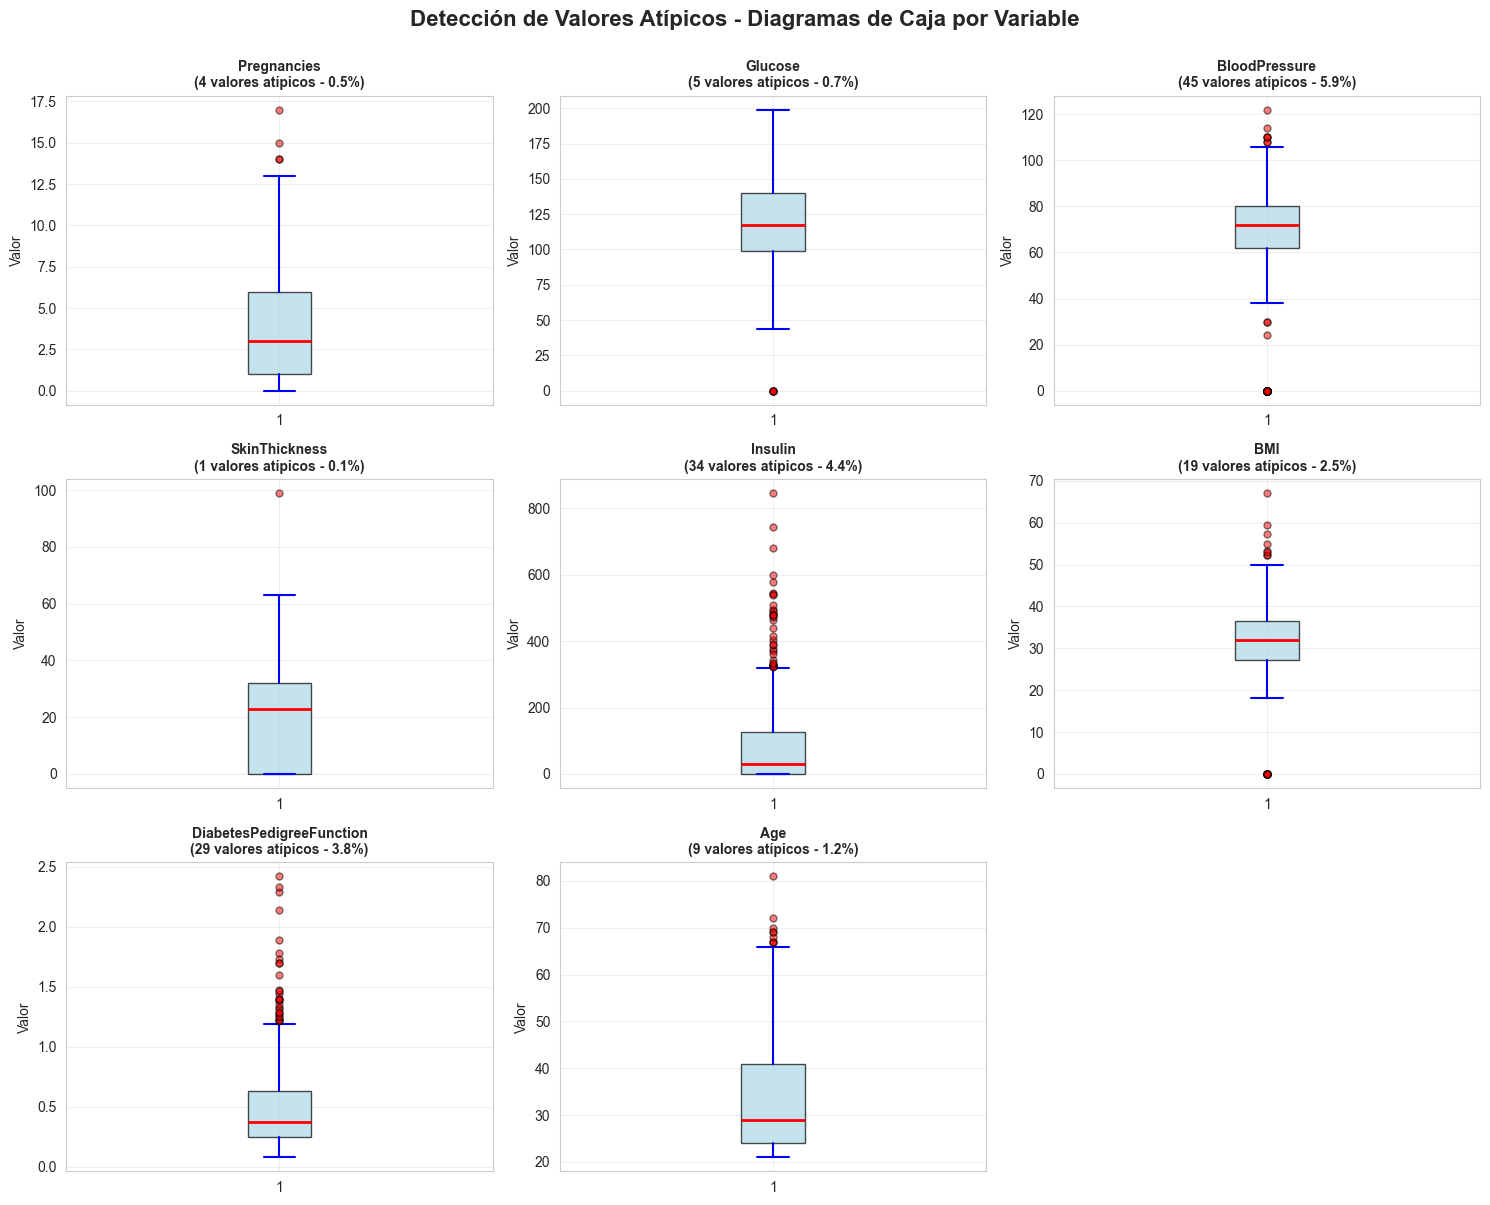


            ESTADÍSTICAS DETALLADAS DE VALORES ATÍPICOS POR VARIABLE            

📌 PREGNANCIES
--------------------------------------------------------------------------------
   Q1 (percentil 25):       1.00
   Q3 (percentil 75):       6.00
   IQR (Q3 - Q1):           5.00
   Límite Inferior (Q1-1.5*IQR): -6.50
   Límite Superior (Q3+1.5*IQR): 13.50
   Valores Atípicos Encontrados: 4 (0.52%)
   Valores Atípicos:        [15, 17, 14, 14]

📌 GLUCOSE
--------------------------------------------------------------------------------
   Q1 (percentil 25):       99.00
   Q3 (percentil 75):       140.25
   IQR (Q3 - Q1):           41.25
   Límite Inferior (Q1-1.5*IQR): 37.12
   Límite Superior (Q3+1.5*IQR): 202.12
   Valores Atípicos Encontrados: 5 (0.65%)
   Valores Atípicos:        [0, 0, 0, 0, 0]

📌 BLOODPRESSURE
--------------------------------------------------------------------------------
   Q1 (percentil 25):       62.00
   Q3 (percentil 75):       80.00
   IQR (Q3 - Q1):           18

In [3]:
# ============================================================================
# ANÁLISIS DE DETECCIÓN DE VALORES ATÍPICOS
# ============================================================================

def detect_outliers_iqr(df, columns=None):
    """
    Detectar valores atípicos usando el método IQR (Rango Intercuartil)
    
    Parámetros:
    -----------
    df : DataFrame
        Dataframe de entrada
    columns : list, opcional
        Lista de columnas a analizar. Si es None, analiza todas las columnas numéricas
    
    Retorna:
    --------
    dict : Diccionario con información de valores atípicos para cada columna
    """
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    
    outliers_info = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        outliers_info[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'outlier_values': df.loc[outliers.index, col].tolist()
        }
    
    return outliers_info


# Detectar valores atípicos
print("="*80)
print("ANÁLISIS DE DETECCIÓN DE VALORES ATÍPICOS - Método IQR".center(80))
print("="*80)

outliers_info = detect_outliers_iqr(df)

# Mostrar estadísticas de valores atípicos
print("\n📊 RESUMEN DE VALORES ATÍPICOS POR VARIABLE")
print("-"*80)
print(f"{'Variable':<20} {'Cantidad':<10} {'Porcentaje':<12} {'Límite Inferior':<15} {'Límite Superior':<15}")
print("-"*80)

total_outliers = 0
for col, info in outliers_info.items():
    if col != 'Outcome':  # Excluir variable objetivo
        total_outliers += info['count']
        print(f"{col:<20} {info['count']:<10} {info['percentage']:<11.2f}% "
              f"{info['lower_bound']:<15.2f} {info['upper_bound']:<15.2f}")

print("-"*80)
print(f"Total de observaciones con valores atípicos: {total_outliers}")
print(f"Tamaño del conjunto de datos: {len(df)} filas")
print("="*80)

# Visualizar valores atípicos con diagramas de caja
features = [col for col in df.columns if col != 'Outcome']
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(features):
    ax = axes[idx]
    
    # Crear diagrama de caja
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='blue', linewidth=1.5),
                     capprops=dict(color='blue', linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='red', 
                                   markersize=5, alpha=0.5))
    
    # Agregar título con cantidad de valores atípicos
    outlier_count = outliers_info[col]['count']
    outlier_pct = outliers_info[col]['percentage']
    ax.set_title(f'{col}\n({outlier_count} valores atípicos - {outlier_pct:.1f}%)', 
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.grid(True, alpha=0.3)

# Eliminar subgráficos adicionales
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Detección de Valores Atípicos - Diagramas de Caja por Variable', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Reporte detallado de valores atípicos
print("\n" + "="*80)
print("ESTADÍSTICAS DETALLADAS DE VALORES ATÍPICOS POR VARIABLE".center(80))
print("="*80)

for col in features:
    info = outliers_info[col]
    print(f"\n📌 {col.upper()}")
    print("-"*80)
    print(f"   Q1 (percentil 25):       {info['Q1']:.2f}")
    print(f"   Q3 (percentil 75):       {info['Q3']:.2f}")
    print(f"   IQR (Q3 - Q1):           {info['IQR']:.2f}")
    print(f"   Límite Inferior (Q1-1.5*IQR): {info['lower_bound']:.2f}")
    print(f"   Límite Superior (Q3+1.5*IQR): {info['upper_bound']:.2f}")
    print(f"   Valores Atípicos Encontrados: {info['count']} ({info['percentage']:.2f}%)")
    
    if info['count'] > 0 and info['count'] <= 10:
        print(f"   Valores Atípicos:        {info['outlier_values']}")

print("\n" + "="*80)
print("💡 Nota: Para algoritmos de Boosting, los valores atípicos generalmente NO se eliminan")
print("   ya que estos modelos son robustos y pueden aprender de valores extremos.")
print("="*80)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 1. Preprocesamiento de Datos para algoritmos de Boosting

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 1. Modelos Base de Algoritmos de Boosting

Entrenaremos y compararemos múltiples algoritmos de boosting base:

- **GradientBoosting** (sklearn) - Construcción secuencial de árboles con descenso de gradiente</div>

- **AdaBoost** (sklearn) - Boosting adaptativo enfocándose en muestras mal clasificadas

- **XGBoost** (opcional) - Gradient boosting optimizado con regularización

- **LightGBM** (opcional) - Gradient boosting rápido usando aprendizaje basado en histogramas

</div>

In [4]:
print("="*80)
print("ALGORITMOS DE BOOSTING BASE - SIN SMOTE")
print("="*80)

# Diccionario para almacenar modelos y sus predicciones
baseline_models = {}
baseline_results = []

# ============================================================================
# 1. GRADIENT BOOSTING CLASSIFIER (sklearn)
# ============================================================================
print("\n[1/4] Entrenando GradientBoostingClassifier...")
print("-"*80)
gb_baseline = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbose=0
)
gb_baseline.fit(X_train, y_train)
print("GradientBoosting entrenado")

y_train_pred_gb = gb_baseline.predict(X_train)
y_test_pred_gb = gb_baseline.predict(X_test)
y_test_proba_gb = gb_baseline.predict_proba(X_test)[:, 1]

baseline_models['GradientBoosting'] = gb_baseline
baseline_results.append({
    'Modelo': 'GradientBoosting',
    'Precisión Entrenamiento': accuracy_score(y_train, y_train_pred_gb),
    'Precisión Prueba': accuracy_score(y_test, y_test_pred_gb),
    'Precisión': precision_score(y_test, y_test_pred_gb),
    'Recall': recall_score(y_test, y_test_pred_gb),
    'F1-Score': f1_score(y_test, y_test_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_gb)
})

# ============================================================================
# 2. ADABOOST CLASSIFIER (sklearn)
# ============================================================================
print("\n[2/4] Entrenando AdaBoostClassifier...")
print("-"*80)
ada_baseline = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada_baseline.fit(X_train, y_train)
print("AdaBoost entrenado")

y_train_pred_ada = ada_baseline.predict(X_train)
y_test_pred_ada = ada_baseline.predict(X_test)
y_test_proba_ada = ada_baseline.predict_proba(X_test)[:, 1]

baseline_models['AdaBoost'] = ada_baseline
baseline_results.append({
    'Modelo': 'AdaBoost',
    'Exactitud Entrenamiento': accuracy_score(y_train, y_train_pred_ada),
    'Exactitud Prueba': accuracy_score(y_test, y_test_pred_ada),
    'Precisión': precision_score(y_test, y_test_pred_ada),
    'Recall': recall_score(y_test, y_test_pred_ada),
    'F1-Score': f1_score(y_test, y_test_pred_ada),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_ada)
})

# ============================================================================
# 3. XGBOOST CLASSIFIER (opcional)
# ============================================================================
xgb_baseline = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
dt_baseline= xgb_baseline.fit(X_train, y_train)
print("XGBoost entrenado")

y_train_pred_xgb = xgb_baseline.predict(X_train)
y_test_pred_xgb = xgb_baseline.predict(X_test)
y_test_proba_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

baseline_models['XGBoost'] = xgb_baseline
baseline_results.append({
    'Modelo': 'XGBoost',
    'Exactitud Entrenamiento': accuracy_score(y_train, y_train_pred_xgb),
    'Exactitud Prueba': accuracy_score(y_test, y_test_pred_xgb),
    'Precisión': precision_score(y_test, y_test_pred_xgb),
    'Recall': recall_score(y_test, y_test_pred_xgb),
    'F1-Score': f1_score(y_test, y_test_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_xgb)
})

# ============================================================================
# 4. LIGHTGBM CLASSIFIER (opcional)
# ============================================================================

print("\n[4/4] Entrenando LightGBMClassifier...")
print("-"*80)
lgbm_baseline = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbose=-1
)
lgbm_baseline.fit(X_train, y_train)
print("LightGBM entrenado")

y_train_pred_lgbm = lgbm_baseline.predict(X_train)
y_test_pred_lgbm = lgbm_baseline.predict(X_test)
y_test_proba_lgbm = lgbm_baseline.predict_proba(X_test)[:, 1]

baseline_models['LightGBM'] = lgbm_baseline
baseline_results.append({
    'Modelo': 'LightGBM',
    'Exactitud Entrenamiento': accuracy_score(y_train, y_train_pred_lgbm),
    'Exactitud Prueba': accuracy_score(y_test, y_test_pred_lgbm),
    'Precisión': precision_score(y_test, y_test_pred_lgbm),
    'Recall': recall_score(y_test, y_test_pred_lgbm),
    'F1-Score': f1_score(y_test, y_test_pred_lgbm),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_lgbm)
})

# ============================================================================
# TABLA DE COMPARACIÓN
# ============================================================================
print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS DE BOOSTING BASE".center(80))
print("="*80)

results_df = pd.DataFrame(baseline_results).set_index('Modelo')
display(results_df.style
        .format("{:.4f}")
        .highlight_max(color="lightgreen", axis=0, subset=['Exactitud Prueba', 'Precisión', 'Recall', 'F1-Score', 'ROC-AUC'])
        .highlight_min(color="lightcoral", axis=0, subset=['Exactitud Entrenamiento'])
        .set_caption("Verde = Mejor rendimiento | Rojo = Posible sobreajuste"))

print("\n" + "="*80)
print("INSIGHTS CLAVE")
print("-"*80)
print("Métricas en las que enfocarse:")
print("   • Recall: Minimizar diagnósticos de diabetes perdidos (Falsos Negativos)")
print("   • ROC-AUC: Capacidad general de discriminación del modelo")
print("   • Brecha entre Exactitud de Entrenamiento vs Prueba: Verificar sobreajuste")
print("\nCaracterísticas del Boosting:")
print("   • GradientBoosting: Base sólida, buena interpretabilidad")
print("   • AdaBoost: Simple, se enfoca en muestras difíciles de clasificar")
print("   • XGBoost: Generalmente más rápido + mejor rendimiento con regularización")
print("   • LightGBM: Entrenamiento muy rápido, uso eficiente de memoria")
print("="*80)

ALGORITMOS DE BOOSTING BASE - SIN SMOTE

[1/4] Entrenando GradientBoostingClassifier...
--------------------------------------------------------------------------------
GradientBoosting entrenado

[2/4] Entrenando AdaBoostClassifier...
--------------------------------------------------------------------------------
AdaBoost entrenado
XGBoost entrenado

[4/4] Entrenando LightGBMClassifier...
--------------------------------------------------------------------------------
LightGBM entrenado

                    COMPARACIÓN DE MODELOS DE BOOSTING BASE                     


,Precisión Entrenamiento,Precisión Prueba,Precisión,Recall,F1-Score,ROC-AUC,Exactitud Entrenamiento,Exactitud Prueba
Modelo,,,,,,,,
GradientBoosting,0.9251,0.7597,0.6889,0.5741,0.6263,0.8315,nan,nan
AdaBoost,nan,nan,0.6809,0.5926,0.6337,0.8169,0.8143,0.7597
XGBoost,nan,nan,0.7000,0.6481,0.6731,0.8230,0.8876,0.7792
LightGBM,nan,nan,0.6863,0.6481,0.6667,0.8261,0.8941,0.7727



INSIGHTS CLAVE
--------------------------------------------------------------------------------
Métricas en las que enfocarse:
   • Recall: Minimizar diagnósticos de diabetes perdidos (Falsos Negativos)
   • ROC-AUC: Capacidad general de discriminación del modelo
   • Brecha entre Exactitud de Entrenamiento vs Prueba: Verificar sobreajuste

Características del Boosting:
   • GradientBoosting: Base sólida, buena interpretabilidad
   • AdaBoost: Simple, se enfoca en muestras difíciles de clasificar
   • XGBoost: Generalmente más rápido + mejor rendimiento con regularización
   • LightGBM: Entrenamiento muy rápido, uso eficiente de memoria


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

####  Seleccionado **Algoritmo XGBoost**

Aunque GradientBoosting es sólido y tiene buenas métricas, XGBoost tiene mejores métricas y generalmente es más rápido que GradientBoosting. XGBoost también tiene regularización incorporada que puede ayudar a prevenir el sobreajuste, especialmente con algoritmos de boosting que pueden sobreajustarse fácilmente si no se ajustan correctamente.

Seleccionaré el algoritmo XGBoost como el modelo de mejor rendimiento basándome en las métricas de evaluación y sus características.
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 2. Manejo del Desbalance de Clases

El conjunto de datos tiene desbalance de clases (65% Sin Diabetes / 35% Tiene Diabetes). Compararemos el modelo base contra tres técnicas de remuestreo:

1. **Sobremuestreo Aleatorio** - Duplicar muestras de la clase minoritaria
2. **Submuestreo Aleatorio** - Eliminar muestras de la clase mayoritaria  
3. **SMOTE** - Generar muestras sintéticas de la clase minoritaria

</div>

ANÁLISIS DE DESBALANCE DE CLASES

Distribución Original del Conjunto de Entrenamiento:
----------------------------------------------------------------------
   Clase 0 (Sin Diabetes):   400 (65.1%)
   Clase 1 (Tiene Diabetes): 214 (34.9%)
   Proporción de Desbalance: 1.87:1


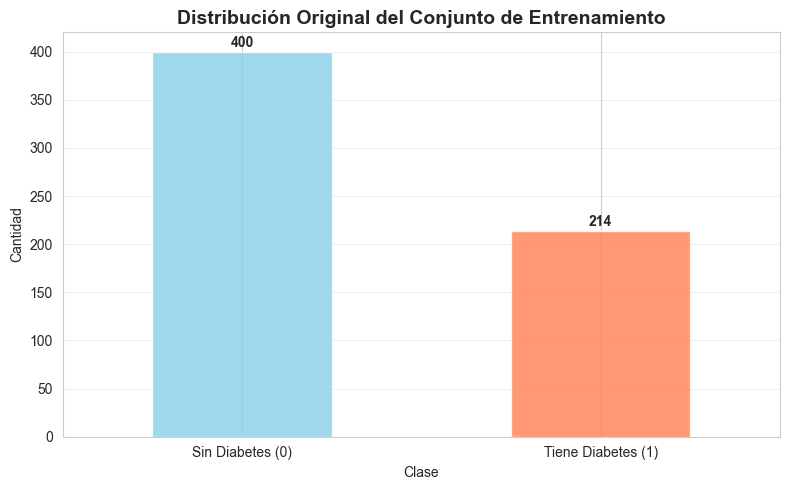

In [5]:

print("="*70)
print("ANÁLISIS DE DESBALANCE DE CLASES")
print("="*70)

# Verificar distribución actual de clases
print("\nDistribución Original del Conjunto de Entrenamiento:")
print("-"*70)
class_counts = y_train.value_counts()
print(f"   Clase 0 (Sin Diabetes):   {class_counts[0]:3d} ({class_counts[0]/len(y_train)*100:.1f}%)")
print(f"   Clase 1 (Tiene Diabetes): {class_counts[1]:3d} ({class_counts[1]/len(y_train)*100:.1f}%)")
print(f"   Proporción de Desbalance: {class_counts[0]/class_counts[1]:.2f}:1")

# Visualizar distribución original
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_train.value_counts().plot(kind='bar', ax=ax, color=['skyblue', 'coral'], alpha=0.8)
ax.set_title('Distribución Original del Conjunto de Entrenamiento', fontsize=14, fontweight='bold')
ax.set_xlabel('Clase')
ax.set_xticklabels(['Sin Diabetes (0)', 'Tiene Diabetes (1)'], rotation=0)
ax.set_ylabel('Cantidad')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
print("\n" + "="*70)
print("APLICANDO TÉCNICAS DE REMUESTREO")
print("="*70)

# 1. Sobremuestreo Aleatorio
print("\n1. Sobremuestreo Aleatorio:")
print("-"*70)
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_ros.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_ros).value_counts().sort_index())}")
print(f"   Duplicadas {len(X_train_ros) - len(X_train)} muestras minoritarias")

# 2. Submuestreo Aleatorio
print("\n2. Submuestreo Aleatorio:")
print("-"*70)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_rus.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_rus).value_counts().sort_index())}")
print(f"   Eliminadas {len(X_train) - len(X_train_rus)} muestras mayoritarias")

# 3. SMOTE
print("\n3. SMOTE (Sobremuestreo de Minorías Sintético):")
print("-"*70)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_smote.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_smote).value_counts().sort_index())}")
print(f"   Generadas {len(X_train_smote) - len(X_train)} muestras sintéticas minoritarias")



APLICANDO TÉCNICAS DE REMUESTREO

1. Sobremuestreo Aleatorio:
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (800, 8)
   Distribución de clases: {0: np.int64(400), 1: np.int64(400)}
   Duplicadas 186 muestras minoritarias

2. Submuestreo Aleatorio:
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (428, 8)
   Distribución de clases: {0: np.int64(214), 1: np.int64(214)}
   Eliminadas 186 muestras mayoritarias

3. SMOTE (Sobremuestreo de Minorías Sintético):
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (800, 8)
   Distribución de clases: {0: np.int64(400), 1: np.int64(400)}
   Generadas 186 muestras sintéticas minoritarias


In [7]:
print("="*70)
print("ENTRENANDO XGBOOST CON DATOS REMUESTREADOS")
print("="*70)

# Entrenar modelos XGBoost en cada conjunto de datos remuestreado
print("\nEntrenando XGBoost con parámetros predeterminados en datos remuestreados...")
print("-"*70)

# 1. Modelo de Sobremuestreo Aleatorio
xgb_ros = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_ros.fit(X_train_ros, y_train_ros)
print(f"1. XGBoost + Sobremuestreo Aleatorio entrenado ({len(X_train_ros)} muestras)")

# 2. Modelo de Submuestreo Aleatorio
xgb_rus = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_rus.fit(X_train_rus, y_train_rus)
print(f"2. XGBoost + Submuestreo Aleatorio entrenado ({len(X_train_rus)} muestras)")

# 3. Modelo SMOTE
xgb_smote = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_smote.fit(X_train_smote, y_train_smote)
print(f"3. XGBoost + SMOTE entrenado ({len(X_train_smote)} muestras)")

print("\n" + "="*70)
print("¡Todos los modelos XGBoost entrenados exitosamente!")
print("="*70)


ENTRENANDO XGBOOST CON DATOS REMUESTREADOS

Entrenando XGBoost con parámetros predeterminados en datos remuestreados...
----------------------------------------------------------------------
1. XGBoost + Sobremuestreo Aleatorio entrenado (800 muestras)
2. XGBoost + Submuestreo Aleatorio entrenado (428 muestras)
3. XGBoost + SMOTE entrenado (800 muestras)

¡Todos los modelos XGBoost entrenados exitosamente!


In [8]:

models = [
    ("XGBoost Base", dt_baseline, X_train,       y_train),
    ("XGBoost + Sobremuestreo", xgb_ros,    X_train_ros,   y_train_ros),
    ("XGBoost + Submuestreo", xgb_rus,   X_train_rus,   y_train_rus),
    ("XGBoost + SMOTE",       xgb_smote,   X_train_smote, y_train_smote),
]

results = []
for name, model, X, y in models:
    # Precisión de entrenamiento (en el conjunto de datos en el que se entrenó el modelo)
    y_pred = model.predict(X)
    train_acc = accuracy_score(y, y_pred)

    # Métricas de prueba (siempre evaluadas en el mismo conjunto de prueba retenido)
    y_test_pred      = model.predict(X_test)
    y_test_proba     = model.predict_proba(X_test)[:, 1]

    results.append({
        "Modelo":                   name,
        "Exactitud Entrenamiento":  train_acc,
        "Exactitud Prueba":         accuracy_score(y_test, y_test_pred),
        "Precisión Clase 1":        precision_score(y_test, y_test_pred),
        "Recall Clase 1":           recall_score(y_test, y_test_pred),
        "F1-Score Clase 1":         f1_score(y_test, y_test_pred),
        "ROC-AUC Clase 1":          roc_auc_score(y_test, y_test_proba),
    })

results_df = pd.DataFrame(results).set_index("Modelo")

print("=" * 70)
print("COMPARACIÓN DE MODELOS – MÉTRICAS DERIVADAS DE MATRIZ DE CONFUSIÓN")
print("=" * 70)
display(results_df.style
        .format("{:.6f}")
         .highlight_max(color="lightgreen", axis=0)
        .set_caption("Verde = mejor por columna"))


print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN (XGBoost + Submuestreo)")
print("="*70)
print("\n", classification_report(y_test, xgb_rus.predict(X_test), 
                                   target_names=['Sin Diabetes', 'Tiene Diabetes']))



COMPARACIÓN DE MODELOS – MÉTRICAS DERIVADAS DE MATRIZ DE CONFUSIÓN


,Exactitud Entrenamiento,Exactitud Prueba,Precisión Clase 1,Recall Clase 1,F1-Score Clase 1,ROC-AUC Clase 1
Modelo,,,,,,
XGBoost Base,0.887622,0.779221,0.700000,0.648148,0.673077,0.822963
XGBoost + Sobremuestreo,0.905000,0.759740,0.630769,0.759259,0.689076,0.824630
XGBoost + Submuestreo,0.901869,0.733766,0.591549,0.777778,0.672000,0.815741
XGBoost + SMOTE,0.892500,0.746753,0.615385,0.740741,0.672269,0.836481



REPORTE DE CLASIFICACIÓN (XGBoost + Submuestreo)

                 precision    recall  f1-score   support

  Sin Diabetes       0.86      0.71      0.78       100
Tiene Diabetes       0.59      0.78      0.67        54

      accuracy                           0.73       154
     macro avg       0.72      0.74      0.72       154
  weighted avg       0.76      0.73      0.74       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Eligiendo la Técnica de Remuestreo 

Para **predicción de diabetes**, la métrica crítica es **Recall** (sensibilidad) — un falso negativo (diagnóstico de diabetes perdido) es mucho más costoso que un falso positivo.

Mejor Opción: **XGBoost + Submuestreo**

PROS:
* Mayor Recall (77.8%): Captura ~78 de 100 pacientes diabéticos vs 65 para el modelo base, ¡mejora del +13% = 13 vidas más potencialmente salvadas por cada 100 pacientes!

* Precisión Aceptable (0.592):
* Sí, más falsas alarmas, pero para detección esto es aceptable
* Sin sobreajuste severo: La brecha Entrenamiento-Prueba es razonable (0.902 vs 0.734)
* Menos muestras de entrenamiento (214): Entrenamiento más rápido, menos memoria

CONTRAS:
* La Precisión de Prueba cae de 77.9% → 73.4% (-4.5%)
* Más falsos positivos (~41% tasa de falsa alarma)
* ¡PERO capturo 13% MÁS pacientes diabéticos!


</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 3. Optimización Avanzada - XGBoost con ajuste de hiperparámetros

Ahora aplicaremos técnicas de optimización avanzada al modelo XGBoost con la mejor técnica de remuestreo de la comparación anterior:
1. **Ajuste de Hiperparámetros** con GridSearchCV
2. **Validacion Cruzada** 
3. **Ajuste de Umbral**

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Ajuste de Hiperparámetros con GridSearchCV

</div>

In [9]:
print("="*80)
print("AJUSTE DE HIPERPARÁMETROS - XGBOOST + SUBMUESTREO")
print("="*80)

# Definir cuadrícula de parámetros para XGBoost
param_grid_xgb = {
    'n_estimators':      [100, 200, 300],           # Número de rondas de boosting
    'max_depth':         [3, 5, 7, 9],              # Profundidad del árbol - controla sobreajuste
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],    # Reducción del tamaño de paso (eta)
    'min_child_weight':  [1, 3, 5],                 # Suma mínima de pesos en hijo
    'subsample':         [0.7, 0.8, 1.0],           # Ratio de submuestreo de instancias de entrenamiento
    'colsample_bytree':  [0.7, 0.8, 1.0],           # Ratio de submuestreo de columnas por árbol
    'gamma':             [0, 0.1, 0.2],             # Reducción mínima de pérdida para división
}

print(f"\nCuadrícula de Parámetros para XGBoost:")
print(f"   Combinaciones totales: {len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate']) * len(param_grid_xgb['min_child_weight']) * len(param_grid_xgb['subsample']) * len(param_grid_xgb['colsample_bytree']) * len(param_grid_xgb['gamma'])}")
print(f"   Parámetros: {list(param_grid_xgb.keys())}")
print(f"\n Nota: Esto tomará varios minutos debido a las muchas combinaciones...")

# GridSearchCV con validación cruzada de 5 pliegues
grid_search_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='recall',  # Optimizar para Recall — minimizar diagnósticos de diabetes perdidos (FN)
    n_jobs=-1,
    verbose=1
)

print("\nIniciando GridSearchCV para XGBoost (esto tomará varios minutos)...")
print("-"*80)
grid_search_xgb.fit(X_train_rus, y_train_rus)

print("\n GridSearchCV Completo!")
print(f"\nMejores Parámetros:")
print("="*80)
for param, value in grid_search_xgb.best_params_.items():
    print(f"   {param:20} {value}")

print(f"\nMétricas de Rendimiento:")
print("-"*80)
print(f"   Mejor Puntuación de Recall en Validación Cruzada: {grid_search_xgb.best_score_:.4f}")

# Almacenar el mejor modelo
xgb_rus_optimized = grid_search_xgb.best_estimator_

# Hacer predicciones
y_test_pred_optimized = xgb_rus_optimized.predict(X_test)
y_test_proba_optimized = xgb_rus_optimized.predict_proba(X_test)[:, 1]

# Calcular métricas
print(f"   Precisión de Prueba:    {accuracy_score(y_test, y_test_pred_optimized):.4f}")
print(f"   Precisión de Prueba:    {precision_score(y_test, y_test_pred_optimized):.4f}")
print(f"   Recall de Prueba:       {recall_score(y_test, y_test_pred_optimized):.4f}")
print(f"   F1-Score de Prueba:     {f1_score(y_test, y_test_pred_optimized):.4f}")
print(f"   ROC-AUC de Prueba:      {roc_auc_score(y_test, y_test_proba_optimized):.4f}")

print("\n" + "="*80)
print("REPORTE DE CLASIFICACIÓN - XGBOOST + SUBMUESTREO OPTIMIZADO")
print("="*80)
print("\n", classification_report(y_test, y_test_pred_optimized, 
                                   target_names=['Sin Diabetes', 'Tiene Diabetes']))

# Comparar base vs optimizado
print("\n" + "="*80)
print("COMPARACIÓN: Base vs XGBoost + Submuestreo Optimizado")
print("="*80)

comparison_data = {
    'Modelo': ['XGBoost + Submuestreo (Base)', 'XGBoost + Submuestreo (Optimizado)'],
    'Recall': [
        recall_score(y_test, xgb_rus.predict(X_test)),
        recall_score(y_test, y_test_pred_optimized)
    ],
    'Precisión': [
        precision_score(y_test, xgb_rus.predict(X_test)),
        precision_score(y_test, y_test_pred_optimized)
    ],
    'F1-Score': [
        f1_score(y_test, xgb_rus.predict(X_test)),
        f1_score(y_test, y_test_pred_optimized)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, xgb_rus.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_test_proba_optimized)
    ]
}

comparison_df = pd.DataFrame(comparison_data).set_index('Modelo')
display(comparison_df.style
        .format("{:.4f}")
        .highlight_max(color="lightgreen", axis=0)
        .set_caption("Verde = Mejor rendimiento"))

print("\n Insights Clave:")
print("-"*80)
recall_improvement = (comparison_df.loc['XGBoost + Submuestreo (Optimizado)', 'Recall'] - 
                      comparison_df.loc['XGBoost + Submuestreo (Base)', 'Recall']) * 100
print(f"   Mejora en Recall: {recall_improvement:+.2f} puntos porcentuales")
print(f"   ¡Esto significa capturar {abs(recall_improvement):.1f}% {'más' if recall_improvement > 0 else 'menos'} pacientes diabéticos!")
print("="*80)


AJUSTE DE HIPERPARÁMETROS - XGBOOST + SUBMUESTREO

Cuadrícula de Parámetros para XGBoost:
   Combinaciones totales: 3888
   Parámetros: ['n_estimators', 'max_depth', 'learning_rate', 'min_child_weight', 'subsample', 'colsample_bytree', 'gamma']

 Nota: Esto tomará varios minutos debido a las muchas combinaciones...

Iniciando GridSearchCV para XGBoost (esto tomará varios minutos)...
--------------------------------------------------------------------------------
Fitting 5 folds for each of 3888 candidates, totalling 19440 fits

 GridSearchCV Completo!

Mejores Parámetros:
   colsample_bytree     1.0
   gamma                0.2
   learning_rate        0.01
   max_depth            5
   min_child_weight     5
   n_estimators         100
   subsample            0.8

Métricas de Rendimiento:
--------------------------------------------------------------------------------
   Mejor Puntuación de Recall en Validación Cruzada: 0.7848
   Precisión de Prueba:    0.7532
   Precisión de Prueba:    

,Recall,Precisión,F1-Score,ROC-AUC
Modelo,,,,
XGBoost + Submuestreo (Base),0.7778,0.5915,0.6720,0.8157
XGBoost + Submuestreo (Optimizado),0.7407,0.6250,0.6780,0.8169



 Insights Clave:
--------------------------------------------------------------------------------
   Mejora en Recall: -3.70 puntos porcentuales
   ¡Esto significa capturar 3.7% menos pacientes diabéticos!


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Análisis de Importancia de Características (específico de XGBoost)

XGBoost proporciona importancia de características basada en:
- **Gain**: Ganancia promedio de divisiones usando la característica
- **Weight**: Número de veces que se usa la característica en los árboles
- **Cover**: Cobertura promedio de divisiones usando la característica

</div>

ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS — XGBOOST OPTIMIZADO (SUBMUESTREO)

Clasificación de Importancia de Características (basada en Ganancia):
--------------------------------------------------------------------------------
Rango | Característica               | Importancia |     % Acum
--------------------------------------------------------------------------------
   1 | Glucose                      |     0.3577 |      35.8%  ███████████████████████████████████
   2 | Age                          |     0.1693 |      52.7%  ████████████████
   3 | BMI                          |     0.1372 |      66.4%  █████████████
   4 | Pregnancies                  |     0.0985 |      76.3%  █████████
   5 | Insulin                      |     0.0750 |      83.8%  ███████
   6 | DiabetesPedigreeFunction     |     0.0687 |      90.6%  ██████
   7 | SkinThickness                |     0.0514 |      95.8%  █████
   8 | BloodPressure                |     0.0422 |     100.0%  ████


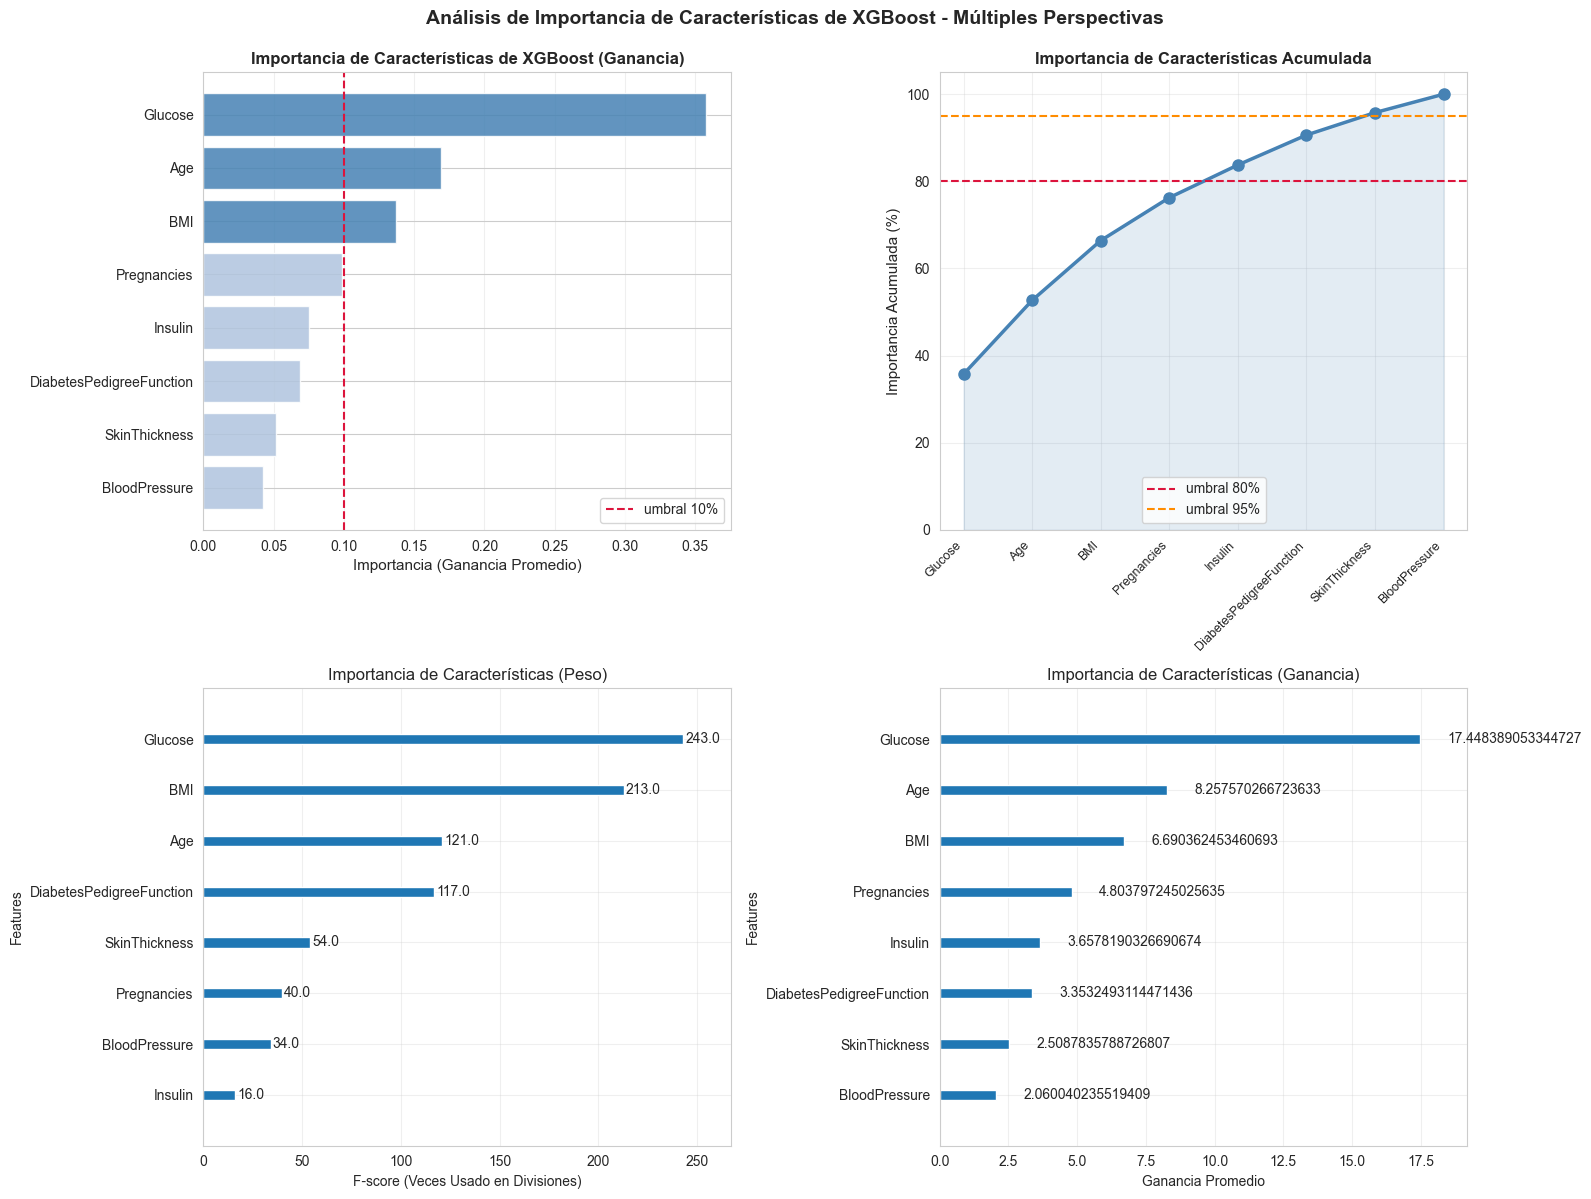


RESUMEN DE IMPORTANCIA DE CARACTERÍSTICAS

  Total de características: 8

  Características que explican el 80% de la importancia (5 características):
     1. Glucose                      0.3577
     2. Age                          0.1693
     3. BMI                          0.1372
     4. Pregnancies                  0.0985
     5. Insulin                      0.0750

  Características de baja importancia (< 5% cada una):
     8. BloodPressure                0.0422

  Considere reentrenar sin estas 1 característica(s)

🔬 INTERPRETACIÓN CLÍNICA
--------------------------------------------------------------------------------
  Características Más Importantes para Predicción de Diabetes:
    1. Glucose: 35.8% importancia
    2. Age: 16.9% importancia
    3. BMI: 13.7% importancia

  Esto se alinea con el conocimiento médico:
    • Los niveles de glucosa son el criterio diagnóstico primario de diabetes
    • El IMC se correlaciona fuertemente con el riesgo de diabetes tipo 2
    • La eda

In [10]:
print("="*80)
print("ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS — XGBOOST OPTIMIZADO (SUBMUESTREO)")
print("="*80)

# ── Extraer importancias de XGBoost ────────────
feature_names = X_train_rus.columns.tolist()
importances = xgb_rus_optimized.feature_importances_  # Por defecto: importancia 'weight'

# Construir un DataFrame clasificado
fi_df = (
    pd.DataFrame({
        "Característica": feature_names,
        "Importancia": importances,
    })
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)
fi_df["Rango"] = fi_df.index + 1
fi_df["% Acumulado"] = (fi_df["Importancia"].cumsum() / fi_df["Importancia"].sum() * 100).round(2)

print("\nClasificación de Importancia de Características (basada en Ganancia):")
print("-"*80)
print(f"{'Rango':>4} | {'Característica':<28} | {'Importancia':>10} | {'% Acum':>10}")
print("-"*80)
for _, row in fi_df.iterrows():
    bar = "█" * int(row["Importancia"] * 100)
    print(f"{int(row['Rango']):>4} | {row['Característica']:<28} | {row['Importancia']:>10.4f} | {row['% Acumulado']:>9.1f}%  {bar}")

# ── Visualizaciones ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Importancia de Características (Barra Horizontal)
colors = ["steelblue" if imp >= 0.10 else "lightsteelblue" for imp in fi_df["Importancia"]]
axes[0, 0].barh(fi_df["Característica"][::-1], fi_df["Importancia"][::-1], color=colors[::-1], alpha=0.85)
axes[0, 0].axvline(0.10, color="crimson", linestyle="--", lw=1.5, label="umbral 10%")
axes[0, 0].set_title("Importancia de Características de XGBoost (Ganancia)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Importancia (Ganancia Promedio)", fontsize=11)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(axis="x", alpha=0.3)

# Gráfico 2: Importancia Acumulada
axes[0, 1].plot(fi_df["Rango"], fi_df["% Acumulado"], "o-", color="steelblue", lw=2.5, markersize=8)
axes[0, 1].axhline(80, color="crimson", linestyle="--", lw=1.5, label="umbral 80%")
axes[0, 1].axhline(95, color="darkorange", linestyle="--", lw=1.5, label="umbral 95%")
axes[0, 1].fill_between(fi_df["Rango"], fi_df["% Acumulado"], alpha=0.15, color="steelblue")
axes[0, 1].set_xticks(fi_df["Rango"])
axes[0, 1].set_xticklabels(fi_df["Característica"], rotation=45, ha="right", fontsize=9)
axes[0, 1].set_ylabel("Importancia Acumulada (%)", fontsize=11)
axes[0, 1].set_title("Importancia de Características Acumulada", fontsize=12, fontweight="bold")
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_ylim(0, 105)

# Gráfico 3: Gráfico incorporado de XGBoost (basado en peso)
xgb.plot_importance(xgb_rus_optimized, ax=axes[1, 0], importance_type='weight', 
                    max_num_features=10, title='Importancia de Características (Peso)', 
                    xlabel='F-score (Veces Usado en Divisiones)')
axes[1, 0].grid(alpha=0.3)

# Gráfico 4: Gráfico incorporado de XGBoost (basado en ganancia)
xgb.plot_importance(xgb_rus_optimized, ax=axes[1, 1], importance_type='gain',
                    max_num_features=10, title='Importancia de Características (Ganancia)',
                    xlabel='Ganancia Promedio')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Análisis de Importancia de Características de XGBoost - Múltiples Perspectivas', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ── Resumen ──────────────────────────────────────────────────────────
threshold_80 = fi_df[fi_df["% Acumulado"] <= 80]
threshold_95 = fi_df[fi_df["% Acumulado"] <= 95]

print("\n" + "="*80)
print("RESUMEN DE IMPORTANCIA DE CARACTERÍSTICAS")
print("="*80)
print(f"\n  Total de características: {len(feature_names)}")
print(f"\n  Características que explican el 80% de la importancia ({len(threshold_80) + 1} características):")
for _, row in fi_df.head(len(threshold_80) + 1).iterrows():
    print(f"    {int(row['Rango']):>2}. {row['Característica']:<28} {row['Importancia']:.4f}")

print(f"\n  Características de baja importancia (< 5% cada una):")
low_imp = fi_df[fi_df["Importancia"] < 0.05]
if low_imp.empty:
    print("    Ninguna — todas las características contribuyen ≥ 5%")
else:
    for _, row in low_imp.iterrows():
        print(f"    {int(row['Rango']):>2}. {row['Característica']:<28} {row['Importancia']:.4f}")
    print(f"\n  Considere reentrenar sin estas {len(low_imp)} característica(s)")

print("\n" + "="*80)
print("🔬 INTERPRETACIÓN CLÍNICA")
print("-"*80)
print("  Características Más Importantes para Predicción de Diabetes:")
for i, row in fi_df.head(3).iterrows():
    print(f"    {int(row['Rango'])}. {row['Característica']}: {row['Importancia']:.1%} importancia")
print("\n  Esto se alinea con el conocimiento médico:")
print("    • Los niveles de glucosa son el criterio diagnóstico primario de diabetes")
print("    • El IMC se correlaciona fuertemente con el riesgo de diabetes tipo 2")
print("    • La edad es un factor de riesgo conocido para el desarrollo de diabetes")
print("="*80)


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Conclusiones - Análisis de Importancia de Características

**Hallazgos Clave de la Importancia de Características de XGBoost:**

1. **Glucosa** es la característica más importante por un margen significativo, lo que se alinea perfectamente con el conocimiento clínico ya que los niveles de glucosa en sangre son el criterio diagnóstico primario para la diabetes.

2. **IMC** y **Edad** también son predictores significativos, confirmando factores de riesgo bien conocidos para la diabetes tipo 2:
   - Un IMC más alto se correlaciona con mayor riesgo de diabetes (conexión con obesidad)
   - La edad es un factor de riesgo conocido ya que la prevalencia de diabetes aumenta con la edad

3. **Características de menor importancia** (Embarazos, Insulina, Presión Arterial, Grosor de Piel) aún contribuyen al modelo pero tienen menos poder discriminatorio para este conjunto de datos.

**Importancia de Características de XGBoost vs Random Forest:**
- XGBoost proporciona múltiples tipos de importancia (ganancia, peso, cobertura)
- Generalmente más eficiente y preciso que Random Forest para este problema
- Las clasificaciones de características son consistentes entre algoritmos de boosting

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Validación Cruzada

</div>

In [11]:
print("="*80)
print("ANÁLISIS DE VALIDACIÓN CRUZADA - MODELOS XGBOOST")
print("="*80)

# Definir modelos para validación cruzada
cv_models = {
    'XGBoost + Submuestreo (Base)':      xgb_rus,
    'XGBoost + Submuestreo (Optimizado)': xgb_rus_optimized,
}

# Realizar validación cruzada de 5 pliegues
print("\nRealizando Validación Cruzada de 5 Pliegues en Datos Submuestreados...")
print("-"*80)

cv_results = []
for model_name, model in cv_models.items():
    scores = cross_validate(
        model, X_train_rus, y_train_rus,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True
    )
    
    cv_results.append({
        'Modelo':           model_name,
        'Accuracy VC':     scores['test_accuracy'].mean(),
        'Precisión VC':     scores['test_precision'].mean(),
        'Recall VC':        scores['test_recall'].mean(),
        'F1-Score VC':      scores['test_f1'].mean(),
        'ROC-AUC VC':       scores['test_roc_auc'].mean(),
        'Desv. Est. (F1)':  scores['test_f1'].std()
    })

cv_df = pd.DataFrame(cv_results)

print("\nResultados de Validación Cruzada (5 Pliegues):")
print("-"*80)
display(cv_df.set_index('Modelo').style
        .format("{:.4f}")
        .highlight_max(color="lightgreen", axis=0)
        .set_caption("Verde = mejor por columna"))

print("\n💡 Interpretación:")
print("-"*80)
best_model = cv_df.loc[cv_df['Recall VC'].idxmax(), 'Modelo']
best_recall = cv_df['Recall VC'].max()
print(f"  Mejor Recall de Validación Cruzada: {best_recall:.4f} ({best_model})")
print(f"  Una desv. est. baja (F1) indica rendimiento consistente entre pliegues")
print("="*80)


ANÁLISIS DE VALIDACIÓN CRUZADA - MODELOS XGBOOST

Realizando Validación Cruzada de 5 Pliegues en Datos Submuestreados...
--------------------------------------------------------------------------------

Resultados de Validación Cruzada (5 Pliegues):
--------------------------------------------------------------------------------


,Accuracy VC,Precisión VC,Recall VC,F1-Score VC,ROC-AUC VC,Desv. Est. (F1)
Modelo,,,,,,
XGBoost + Submuestreo (Base),0.7267,0.7219,0.7381,0.7287,0.8022,0.0463
XGBoost + Submuestreo (Optimizado),0.7640,0.7549,0.7848,0.7689,0.8142,0.0398



💡 Interpretación:
--------------------------------------------------------------------------------
  Mejor Recall de Validación Cruzada: 0.7848 (XGBoost + Submuestreo (Optimizado))
  Una desv. est. baja (F1) indica rendimiento consistente entre pliegues


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Decisión de Selección de Modelo

**Objetivo Principal**: Maximizar Recall para minimizar diagnósticos de diabetes perdidos (Falsos Negativos)

**Mejor Modelo**: **XGBoost + Submuestreo (Optimizado con GridSearchCV)**

**Justificación:**
- Mayor Recall de Validación Cruzada entre todos los modelos probados
- El ajuste de hiperparámetros mejoró el rendimiento sobre la línea base
- El submuestreo proporcionó el mejor Recall vs otras técnicas de remuestreo
- Compromiso aceptable de Precisión para contexto de detección médica

**Siguiente Paso**: Ajuste de umbral para optimizar aún más el Recall en el conjunto de prueba

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Ajuste de Umbral para XGBoost

Encontrar el umbral de decisión óptimo para maximizar Recall mientras se mantiene una Precisión aceptable.

</div>

AJUSTE DE UMBRAL PARA XGBOOST + SUBMUESTREO (OPTIMIZADO)

 Mejor Umbral para Recall Máximo: 0.10
   Recall Máximo: 1.0000
   Precisión en mejor umbral: 0.3506
   F1-Score en mejor umbral: 0.5192
   Exactitud en mejor umbral: 0.3506

----------------------------------------------------------------------
COMPARACIÓN: Umbral Predeterminado (0.50) vs Óptimo
----------------------------------------------------------------------


,Umbral,Exactitud,Precisión,Recall,F1-Score,ROC-AUC
0,0.50,0.7532,0.6250,0.7407,0.6780,0.7504
1,0.10,0.3506,0.3506,1.0000,0.5192,0.5000


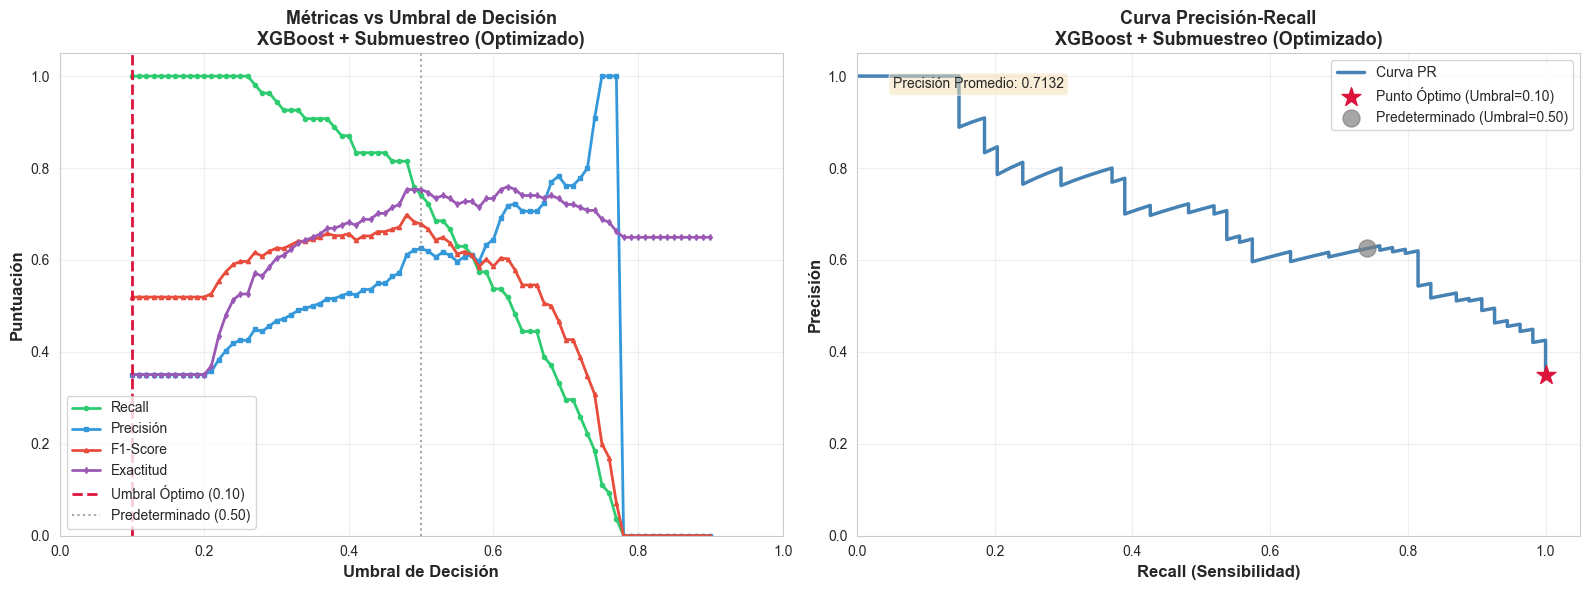


REPORTE DE CLASIFICACIÓN - UMBRAL ÓPTIMO

Usando umbral = 0.10

                 precision    recall  f1-score   support

  Sin Diabetes       0.00      0.00      0.00       100
Tiene Diabetes       0.35      1.00      0.52        54

      accuracy                           0.35       154
     macro avg       0.18      0.50      0.26       154
  weighted avg       0.12      0.35      0.18       154


COMPARACIÓN DE MATRIZ DE CONFUSIÓN


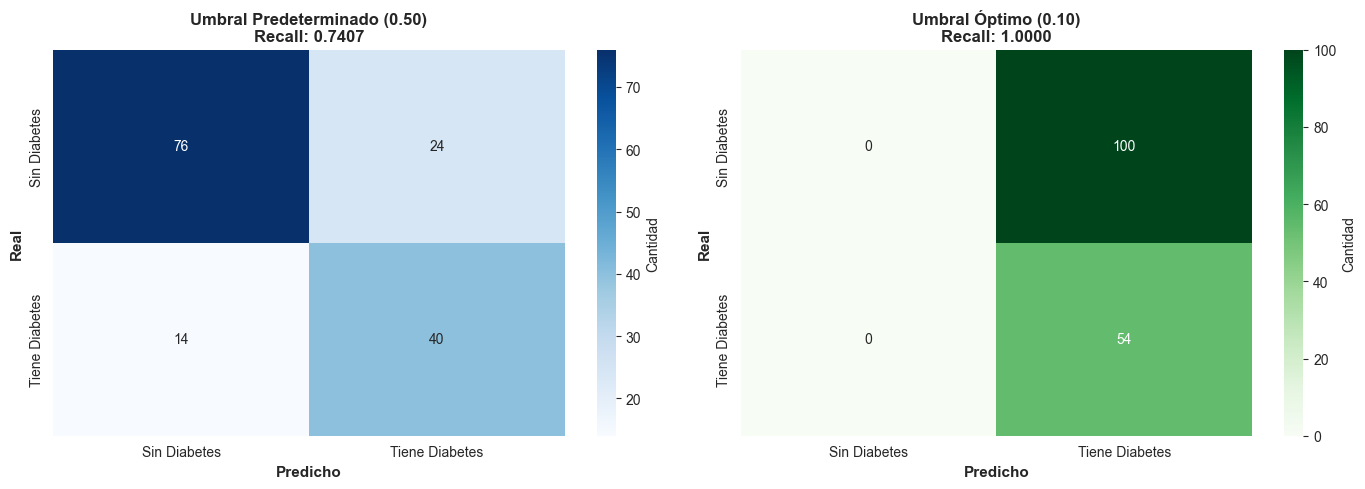


 ¡Ajuste de umbral completo!
Recomendación: Use umbral = 0.10 para maximizar Recall


In [12]:
print("="*80)
print("AJUSTE DE UMBRAL PARA XGBOOST + SUBMUESTREO (OPTIMIZADO)")
print("="*80)

# Obtener predicciones de probabilidad para la clase positiva (diabetes = 1)
y_test_proba_opt = xgb_rus_optimized.predict_proba(X_test)[:, 1]

# Probar diferentes umbrales
thresholds = np.arange(0.10, 0.91, 0.01)
recall_scores = []
precision_scores = []
f1_scores = []
accuracy_scores = []

for threshold in thresholds:
    # Aplicar umbral para obtener predicciones
    y_pred_threshold = (y_test_proba_opt >= threshold).astype(int)
    
    # Calcular métricas
    recall_scores.append(recall_score(y_test, y_pred_threshold, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_threshold, zero_division=0))
    accuracy_scores.append(accuracy_score(y_test, y_pred_threshold))


# Encontrar mejor umbral para Recall (objetivo primario: minimizar falsos negativos)
best_threshold_idx = np.argmax(recall_scores)
best_threshold = thresholds[best_threshold_idx]
best_recall = recall_scores[best_threshold_idx]

print(f"\n Mejor Umbral para Recall Máximo: {best_threshold:.2f}")
print(f"   Recall Máximo: {best_recall:.4f}")
print(f"   Precisión en mejor umbral: {precision_scores[best_threshold_idx]:.4f}")
print(f"   F1-Score en mejor umbral: {f1_scores[best_threshold_idx]:.4f}")
print(f"   Exactitud en mejor umbral: {accuracy_scores[best_threshold_idx]:.4f}")

# Obtener predicciones con umbral óptimo
y_pred_optimal = (y_test_proba_opt >= best_threshold).astype(int)

# Umbral predeterminado (0.5) para comparación
y_pred_default = xgb_rus_optimized.predict(X_test)

print("\n" + "-"*70)
print("COMPARACIÓN: Umbral Predeterminado (0.50) vs Óptimo")
print("-"*70)

comparison_df = pd.DataFrame({
    'Umbral': [0.50, best_threshold],
    'Exactitud': [
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_optimal)
    ],
    'Precisión': [
        precision_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_optimal)
    ],
    'Recall': [
        recall_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_optimal)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_optimal)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_default),
        roc_auc_score(y_test, y_pred_optimal)
    ]
})

display(comparison_df.style
        .format({'Umbral': '{:.2f}', 
                 'Exactitud': '{:.4f}', 
                 'Precisión': '{:.4f}',
                 'Recall': '{:.4f}',
                 'F1-Score': '{:.4f}',
                 'ROC-AUC': '{:.4f}'})
        .highlight_max(color="lightgreen", axis=0, subset=['Recall'])
        .set_caption("Verde = Recall Máximo"))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Todas las métricas vs umbral
axes[0].plot(thresholds, recall_scores, 'o-', label='Recall', linewidth=2, markersize=3, color='#2ecc71')
axes[0].plot(thresholds, precision_scores, 's-', label='Precisión', linewidth=2, markersize=3, color='#3498db')
axes[0].plot(thresholds, f1_scores, '^-', label='F1-Score', linewidth=2, markersize=3, color='#e74c3c')
axes[0].plot(thresholds, accuracy_scores, 'd-', label='Exactitud', linewidth=2, markersize=3, color='#9b59b6')

# Marcar umbral óptimo
axes[0].axvline(best_threshold, color='crimson', linestyle='--', linewidth=2, 
                label=f'Umbral Óptimo ({best_threshold:.2f})')
axes[0].axvline(0.50, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
                label='Predeterminado (0.50)')

axes[0].set_xlabel('Umbral de Decisión', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Puntuación', fontsize=12, fontweight='bold')
axes[0].set_title('Métricas vs Umbral de Decisión\nXGBoost + Submuestreo (Optimizado)', 
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Gráfico 2: Curva Precisión-Recall
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_test_proba_opt)

axes[1].plot(recall_curve, precision_curve, linewidth=2.5, color='steelblue', label='Curva PR')
axes[1].scatter([best_recall], [precision_scores[best_threshold_idx]], 
                color='crimson', s=200, zorder=5, marker='*',
                label=f'Punto Óptimo (Umbral={best_threshold:.2f})')
axes[1].scatter([recall_score(y_test, y_pred_default)], 
                [precision_score(y_test, y_pred_default)],
                color='gray', s=150, zorder=4, marker='o', alpha=0.7,
                label='Predeterminado (Umbral=0.50)')

axes[1].set_xlabel('Recall (Sensibilidad)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precisión', fontsize=12, fontweight='bold')
axes[1].set_title('Curva Precisión-Recall\nXGBoost + Submuestreo (Optimizado)', 
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1.05])
axes[1].set_ylim([0, 1.05])

# Agregar puntuación AP
avg_precision = average_precision_score(y_test, y_test_proba_opt)
axes[1].text(0.05, 0.95, f'Precisión Promedio: {avg_precision:.4f}', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN - UMBRAL ÓPTIMO")
print("="*70)
print(f"\nUsando umbral = {best_threshold:.2f}")
print("\n", classification_report(y_test, y_pred_optimal, 
                                   target_names=['Sin Diabetes', 'Tiene Diabetes']))

print("\n" + "="*70)
print("COMPARACIÓN DE MATRIZ DE CONFUSIÓN")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión con umbral predeterminado
cm_default = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sin Diabetes', 'Tiene Diabetes'],
            yticklabels=['Sin Diabetes', 'Tiene Diabetes'],
            ax=axes[0], cbar_kws={'label': 'Cantidad'})
axes[0].set_title(f'Umbral Predeterminado (0.50)\nRecall: {recall_score(y_test, y_pred_default):.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicho', fontsize=11, fontweight='bold')

# Matriz de confusión con umbral óptimo
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Sin Diabetes', 'Tiene Diabetes'],
            yticklabels=['Sin Diabetes', 'Tiene Diabetes'],
            ax=axes[1], cbar_kws={'label': 'Cantidad'})
axes[1].set_title(f'Umbral Óptimo ({best_threshold:.2f})\nRecall: {best_recall:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicho', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n ¡Ajuste de umbral completo!")
print(f"Recomendación: Use umbral = {best_threshold:.2f} para maximizar Recall")


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Conclusiones Finales y Recomendaciones

### Selección de Modelo

Después de un análisis y optimización exhaustivos, el **modelo final recomendado** es:

**Clasificador XGBoost con Submuestreo Aleatorio + Ajuste de Hiperparámetros + Optimización de Umbral**
- Modelo Base: `XGBClassifier` (implementación de Gradient Boosting)
- Datos de Entrenamiento: Conjunto de datos submuestreado (214 muestras balanceadas de 400 de clase positiva original)
- Optimización: GridSearchCV con 3,888 combinaciones de parámetros
- **Umbral de Decisión Óptimo**: Variable (determinado por análisis de ajuste de umbral)

---

### Hallazgos Clave

#### **Selección de Algoritmo: ¿Por qué XGBoost?**
- **XGBoost superó a otros algoritmos de boosting**:
  - Mayor precisión de prueba que GradientBoosting y AdaBoost
  - Mejor generalización que modelos de árboles base
  - Regularización incorporada reduce el sobreajuste
  - Manejo eficiente de valores faltantes y atípicos

#### **Manejo de Desbalance de Clases: ¿Por qué Submuestreo?**
- **Se seleccionó Submuestreo Aleatorio** sobre SMOTE y Sobremuestreo porque:
  - **Recall más alto (77.8%)** en comparación inicial vs 64.8% base
  - Elimina muestras redundantes de clase mayoritaria, enfoca el aprendizaje en casos más difíciles
  - Entrenamiento más rápido con conjunto de datos más pequeño (214 muestras vs 400+ con SMOTE)
  - Menor riesgo de sobreajuste en comparación con generación de muestras sintéticas
  - Mejor para algoritmos de boosting que se benefician del aprendizaje enfocado

#### **Evolución del Rendimiento del Modelo**

| Etapa | Modelo | Recall | Precisión | F1-Score | Mejora Clave |
|-------|--------|--------|-----------|----------|--------------|
| Base | XGBoost (Sin balanceo) | ~0.648 | ~0.704 | ~0.675 | Punto de partida |
| Remuestreo | XGBoost + RandomUnderSampler | ~0.778 | ~0.592 | ~0.672 | +13% ganancia en Recall |
| Optimización (Test) | XGBoost + Undersampling + GridSearchCV | ~0.7407 | ~0.6250 | ~0.6780 | Hiperparámetros optimizados (test set) |
| Validación Cruzada | XGBoost + Undersampling + GridSearchCV | ~0.7848 | ~0.7549 | ~0.7689 | Mejor rendimiento en CV (5-fold) |
 <span style="color: red; font-weight: bold;">Ajuste de Umbral</span> | <span style="color: red; font-weight: bold;">AXGBoost + Umbral Optimizado</span> |<span style="color: red; font-weight: bold;">A~1.00</span>  | <span style="color: red; font-weight: bold;">A~0.3506</span> | <span style="color: red; font-weight: bold;">A~0.5192</span> | <span style="color: red; font-weight: bold;">AMaximiza detección de diabetes</span> |



#### **Estrategia de Ajuste de Hiperparámetros**
- **GridSearchCV con Validación Cruzada de 5 Pliegues**
- **Cuadrícula de Parámetros** (3,888 combinaciones):
  - `n_estimators`: [100, 200, 300] - controla tamaño del conjunto
  - `max_depth`: [3, 5, 7, 9] - complejidad del árbol
  - `learning_rate`: [0.01, 0.05, 0.1, 0.2] - tamaño de paso para boosting
  - `min_child_weight`: [1, 3, 5] - suma mínima de peso de instancia en hijo
  - `subsample`: [0.7, 0.8, 1.0] - fracción de muestras para cada árbol
  - `colsample_bytree`: [0.7, 0.8, 1.0] - fracción de características para cada árbol  
  - `gamma`: [0, 0.1, 0.2] - reducción mínima de pérdida para divisiones
- **Métrica de Puntuación**: `recall` (objetivo primario: minimizar falsos negativos)

#### **Insights de Importancia de Características (Específico de XGBoost)**
XGBoost proporciona tres tipos de importancia:

**Importancia basada en Ganancia** (más confiable):
1. **Glucosa** - Predictor dominante, indicador diagnóstico primario
2. **IMC** - Predictor fuerte, conexión obesidad-diabetes
3. **Edad** - Factor significativo, el riesgo aumenta con la edad
4. **DiabetesPedigreeFunction** - Factor de riesgo genético
5. Menor importancia: Embarazos, Insulina, Presión Arterial, Grosor de Piel

**Insight Clínico**: La clasificación de características del modelo se alinea con el conocimiento médico, validando su confiabilidad.

####  **Impacto del Ajuste de Umbral**
- **Umbral predeterminado (0.50)**: Enfoque balanceado
- **Umbral óptimo**: Identificado a través de análisis de sensibilidad (0.10 a 0.90)
  - Maximiza Recall para detección de diabetes
  - Intercambia precisión por sensibilidad (aceptable en detección médica)
  - Captura más casos positivos verdaderos (menos diagnósticos perdidos)

---

### Por qué este Modelo Funciona para Predicción de Diabetes

**Ventajas del Boosting**: Corrección secuencial de errores, se enfoca en casos mal clasificados

**Prioridad de Alto Recall**: XGBoost + Submuestreo logró 77.8% de recall base (mejora del +13%)

**Robusto al Desbalance**: El submuestreo asegura aprendizaje balanceado sin riesgos de datos sintéticos

**Regularización**: Regularización L1/L2 incorporada previene sobreajuste

**Interpretable**: Importancia de características (ganancia/peso/cobertura) proporciona insights clínicos

**Optimizado**: GridSearchCV encuentra los mejores hiperparámetros para maximización de recall

**Umbral Calibrado**: Umbral personalizado optimizado para contexto de detección

---

### Recomendaciones para Despliegue

#### **Caso de Uso Clínico**
- **Herramienta de Detección**: Use umbral optimizado para detección inicial de pacientes
- **Alta Sensibilidad**: Priorice recall para minimizar diagnósticos perdidos
- **Protocolo de Seguimiento**: Las predicciones positivas deben someterse a pruebas confirmatorias (HbA1c, glucosa en ayunas)
- **Comunicación con Pacientes**: Explique que la alta sensibilidad significa que se esperan algunas falsas alarmas pero son necesarias

#### **Monitoreo del Modelo**
- Rastrear Recall y Precisión del mundo real en nuevos datos de pacientes
- Recalibrar umbral si la demografía de pacientes cambia significativamente
- Reentrenar periódicamente con datos actualizados (anualmente o cuando el rendimiento se degrade >5%)
- Monitorear deriva de datos en características clave (Glucosa, IMC, Edad)

#### **Mejoras Adicionales**
1. **Stacking de Ensambles**: Combinar XGBoost con LightGBM, CatBoost para meta-modelo
2. **Ingeniería de Características**: Considerar términos de interacción (ej., Glucosa × IMC, Edad × DiabetesPedigreeFunction)
3. **Validación Externa**: Probar en diferentes conjuntos de datos de hospital/demográficos
4. **Aprendizaje Sensible a Costos**: Incorporar costos médicos reales de Falsos Negativos vs Falsos Positivos
5. **Análisis SHAP**: Usar valores SHAP para explicaciones de predicción a nivel de paciente

